# BA820: Milestone III - Integrated Analysis & Synergy
**Course:** BA820 - Unsupervised and Unstructured Machine Learning

**Author:** Riya Poojary, Daksh Raichura, Sanskruti Pawar, Michael Allieri

**Dataset:** Hollywood Age Gaps (age_gaps.csv)


## I. Dataset Overview: Hollywood Age Gaps

In Milestone 2, each team member independently explored the age gap dataset using different preprocessing decisions, feature constructions, and analytical methods.

- Riya focused on identifying patterns in age gap magnitude using clustering.
- Sanskruti analyzed the role of actor age distributions and performed dimensionality reduction.
- Daksh explored whether large age gaps are driven more by older actors being unusually old or younger actors being unusually young.

In Milestone 3, we integrate these approaches by:
1. Standardizing preprocessing across members.
2. Comparing feature representations.
3. Testing clustering stability under unified and individual feature sets.
4. Evaluating whether combined representations produce stronger or more interpretable structures.

Our goal is to determine whether integration leads to stronger insights or reveals structural redundancies across approaches.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage


# Load dataset
df = pd.read_csv("age_gaps.csv")
df.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


## II. Unified Feature Engineering

During Milestone 2, team members explored different feature constructions and interpretations of age differences.

To integrate these approaches, we construct a unified feature space that includes:
- Raw actor ages
- Age gap
- Average age
- Older actor age
- Younger actor age




In [52]:
# Ensure numeric columns
df['age_gap'] = df['actor_1_age'] - df['actor_2_age']
df['avg_age'] = (df['actor_1_age'] + df['actor_2_age']) / 2
df['older_actor'] = df[['actor_1_age', 'actor_2_age']].max(axis=1)
df['younger_actor'] = df[['actor_1_age', 'actor_2_age']].min(axis=1)

df[['actor_1_age','actor_2_age','age_gap','avg_age','older_actor','younger_actor']].head()

,actor_1_age,actor_2_age,age_gap,avg_age,older_actor,younger_actor
0,75,23,52,49.0,75,23
1,74,24,50,49.0,74,24
2,69,20,49,44.5,69,20
3,68,23,45,45.5,68,23
4,81,38,43,59.5,81,38


The table above confirms the unified features were created correctly. `age_gap` captures the difference between the two actor ages, `avg_age` is the mean age and `older_actor` , `younger_actor` store the max, min age for each pair.

## III. Reconstructing Individual Feature Sets

Each team member used a slightly different feature representation:

- Riya focused primarily on age gap magnitude.
- Sanskruti emphasized actor age distributions.
- Daksh examined asymmetry between older and younger actors.

We reconstruct these feature sets to allow direct comparison under a standardized preprocessing and clustering pipeline.


In [53]:
features_riya = ['age_gap']
features_sanskruti = ['actor_1_age', 'actor_2_age']
features_daksh = ['older_actor', 'younger_actor', 'age_gap']

features_unified = [
    'actor_1_age',
    'actor_2_age',
    'age_gap',
    'avg_age',
    'older_actor',
    'younger_actor'
]

print("\nRiya Preview:")
display(df[features_riya].head())

print("\nSanskruti Preview:")
display(df[features_sanskruti].head())

print("\nDaksh Preview:")
display(df[features_daksh].head())

print("\nUnified Preview:")
display(df[features_unified].head())


Riya Preview:


,age_gap
0,52
1,50
2,49
3,45
4,43



Sanskruti Preview:


,actor_1_age,actor_2_age
0,75,23
1,74,24
2,69,20
3,68,23
4,81,38



Daksh Preview:


,older_actor,younger_actor,age_gap
0,75,23,52
1,74,24,50
2,69,20,49
3,68,23,45
4,81,38,43



Unified Preview:


,actor_1_age,actor_2_age,age_gap,avg_age,older_actor,younger_actor
0,75,23,52,49.0,75,23
1,74,24,50,49.0,74,24
2,69,20,49,44.5,69,20
3,68,23,45,45.5,68,23
4,81,38,43,59.5,81,38


## IV. Preprocessing Sensitivity: Scaling Effects

In Milestone 2, different preprocessing techniques were used across team members, including StandardScaler and MinMaxScaler.

Because clustering algorithms are sensitive to scale, we test whether scaling choices materially impact segmentation results.

This step represents our first explicit integration attempt: evaluating representation stability across preprocessing decisions.


In [54]:
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_standard = scaler_standard.fit_transform(df[features_unified])
X_minmax = scaler_minmax.fit_transform(df[features_unified])

print("X_standard shape:", X_standard.shape)
print("X_minmax shape:", X_minmax.shape)

X_standard shape: (1155, 6)
X_minmax shape: (1155, 6)


- Both scaled matrices have shape (1155, 6), confirming that scaling changed only the feature values (units) and did not change the number of observations or features.
- This ensures a fair comparison of clustering results across scaling methods.

### IV.A Feature Correlation and Redundancy (Unified Set)

Before running PCA and clustering, we check correlations among the unified features. This helps us see whether some engineered variables are repeating the same information. Very high correlations suggest redundancy, meaning adding more features may not meaningfully change clustering results.

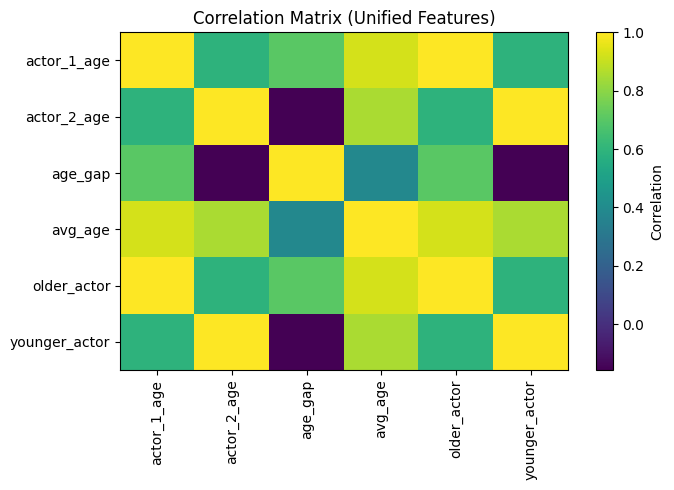

,actor_1_age,actor_2_age,age_gap,avg_age,older_actor,younger_actor
actor_1_age,1.000,0.591,0.704,0.926,1.000,0.591
actor_2_age,0.591,1.000,-0.156,0.852,0.591,1.000
age_gap,0.704,-0.156,1.000,0.384,0.704,-0.156
avg_age,0.926,0.852,0.384,1.000,0.926,0.852
older_actor,1.000,0.591,0.704,0.926,1.000,0.591
younger_actor,0.591,1.000,-0.156,0.852,0.591,1.000


In [55]:
corr = df[features_unified].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Unified Features)")
plt.tight_layout()
plt.show()

display(corr.round(3))

- `older_actor` and `actor_1_age` are perfectly correlated because they represent the same value by construction
- `younger_actor` and `actor_2_age` are also perfectly correlated for the same reason
- `avg_age` is strongly related to both actor ages because it is computed from them
- `age_gap` behaves differently because it captures the difference between ages, not the overall age level
- Overall, the unified feature set contains overlap, which helps explain why adding more derived age features does not strongly improve segmentation

## V. PCA Results and Interpretation

We use PCA to summarize the unified feature set into a smaller number of dimensions. We run PCA under both StandardScaler and MinMaxScaler to check whether the main structure is consistent across scaling choices. We compare variance explained and the 2D PCA projection.


In [56]:
pca_standard = PCA(n_components=2)
X_pca_standard = pca_standard.fit_transform(X_standard)

pca_minmax = PCA(n_components=2)
X_pca_minmax = pca_minmax.fit_transform(X_minmax)

print("Explained variance (StandardScaler):", pca_standard.explained_variance_ratio_)
print("Explained variance (MinMaxScaler):", pca_minmax.explained_variance_ratio_)

Explained variance (StandardScaler): [0.72067892 0.27932108]
Explained variance (MinMaxScaler): [0.72469387 0.27530613]


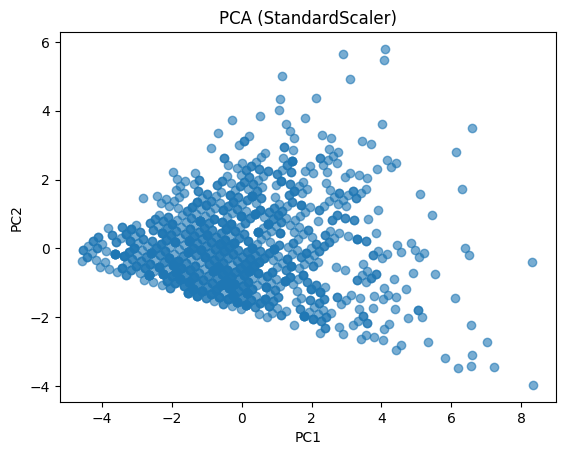

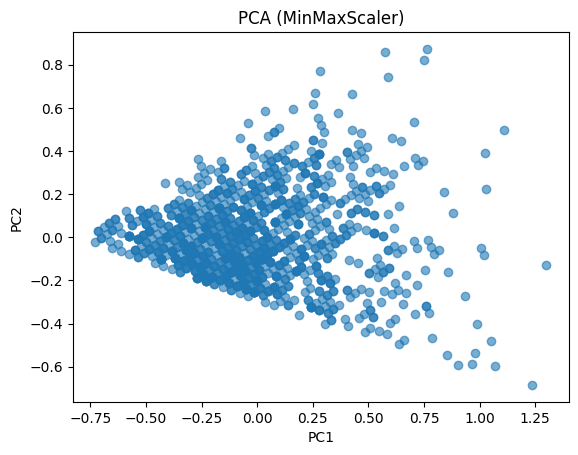

In [57]:
plt.figure()
plt.scatter(X_pca_std[:, 0], X_pca_std[:, 1], alpha=0.6)
plt.title("PCA (StandardScaler)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(X_pca_mm[:, 0], X_pca_mm[:, 1], alpha=0.6)
plt.title("PCA (MinMaxScaler)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

- The explained variance ratios are very similar under both scalers (PC1 is about 72 percent and PC2 is about 28 percent).

- The first two PCs explain a very similar share of variance under both scalers, suggesting the dominant structure is stable across scaling

- The PCA scatter shows a continuous spread rather than clearly separated groups, so PCA helps more with visualization and interpretation than with forming obvious clusters

### V.A Choosing the Number of PCs: Scree/Elbow

- The scree plot shows how quickly variance accumulates as we add more principal components (PCs).

- This helps justify how many PCs are enough for visualization and interpretation.

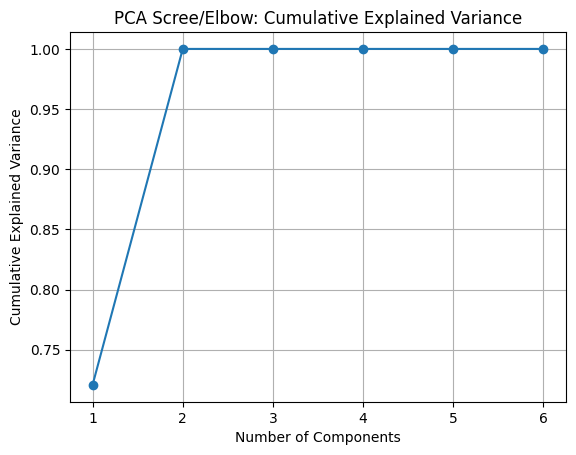

In [58]:
X_std = StandardScaler().fit_transform(df[features_unified])

pca_full = PCA()
pca_full.fit(X_std)

explained = pca_full.explained_variance_ratio_
cum_explained = explained.cumsum()

plt.figure()
plt.plot(range(1, len(explained) + 1), cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree/Elbow: Cumulative Explained Variance")
plt.grid(True)
plt.show()

- The curve rises sharply by PC2 and then becomes nearly flat
- This suggests two components capture almost all meaningful variance in the unified feature set
- This supports the idea that many engineered age features are redundant

### V.B Interpreting PCs: PCA Loadings

PCA loadings show how each original feature contributes to each principal component. This is different from the correlation matrix, which only shows relationships among the original features. We focus on the largest absolute loadings to identify the main drivers of PC1 and PC2.

In [59]:
X_std = StandardScaler().fit_transform(df[features_unified])

pca_2 = PCA(n_components=2)
pca_2.fit(X_std)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=features_unified,
    columns=["PC1_loading", "PC2_loading"]
)

display(loadings.round(3))

# Top drivers for interpretation
print("Top features driving PC1 (by absolute loading):")
display(loadings["PC1_loading"].abs().sort_values(ascending=False).head(5))

print("Top features driving PC2 (by absolute loading):")
display(loadings["PC2_loading"].abs().sort_values(ascending=False).head(5))

,PC1_loading,PC2_loading
actor_1_age,0.456,0.247
actor_2_age,0.394,-0.444
age_gap,0.211,0.694
avg_age,0.480,-0.047
older_actor,0.456,0.247
younger_actor,0.394,-0.444


Top features driving PC1 (by absolute loading):


,PC1_loading
avg_age,0.480013
older_actor,0.455612
actor_1_age,0.455612
actor_2_age,0.393521
younger_actor,0.393521


Top features driving PC2 (by absolute loading):


,PC2_loading
age_gap,0.693786
actor_2_age,0.443996
younger_actor,0.443996
older_actor,0.247185
actor_1_age,0.247185


- PC1 is driven most by overall age level features such as `avg_age`, `actor_1_age` and `older_actor`
- PC2 is driven most by `age_gap`, which captures age difference rather than age level
- This matches our main takeaway that age gap magnitude explains a large portion of the structure, while additional derived features mostly refine interpretation

## VI. Baseline Clustering Results: KMeans

We now apply KMeans clustering to both standardized and min-max scaled data.

The objective is to evaluate:
- Silhouette score differences
- Whether scaling materially changes segmentation quality
- Whether cluster assignments remain consistent

This directly tests whether preprocessing differences from Milestone 2 influenced individual conclusions.


In [60]:
kmeans_standard = KMeans(n_clusters=3, random_state=42)
labels_standard = kmeans_standard.fit_predict(X_standard)

kmeans_minmax = KMeans(n_clusters=3, random_state=42)
labels_minmax = kmeans_minmax.fit_predict(X_minmax)

In [61]:
silhouette_standard = silhouette_score(X_standard, labels_standard)
silhouette_minmax = silhouette_score(X_minmax, labels_minmax)

print("Silhouette (StandardScaler):", silhouette_standard)
print("Silhouette (MinMaxScaler):", silhouette_minmax)

Silhouette (StandardScaler): 0.4172817929664953
Silhouette (MinMaxScaler): 0.3374639091555247


- **k = 3** clusters used for KMeans on both scaled datasets

- **StandardScaler silhouette** ≈ 0.417 (better separation)

- **MinMaxScaler silhouette** ≈ 0.337 (weaker separation)

- **Interpretation:** Standardization gives slightly cleaner clusters, but separation is still moderate (some overlap)

- **Next step:** check stability of cluster assignments across scalers (e.g., ARI)

## VII. Robustness Check: Ward vs KMeans
In Milestone 2, Riya implemented KMeans on the standardized unified feature space to segment actor pairs based on `age-gap` distributional profiles. While the clusters appeared interpretable, a key question remained:

**Is the observed segmentation a property of the data itself or an artifact of centroid-based initialization?**

To address this through team-level integration, we introduce hierarchical clustering using Ward’s method. Ward’s approach differs fundamentally from KMeans:

- It does not rely on random centroid initialization.

- It builds clusters bottom-up by minimizing within-cluster variance.

- It provides a hierarchical structure (dendrogram) rather than a single flat partition.

In [62]:
# Hierarchical Clustering using Ward's method
ward_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ward = ward_model.fit_predict(X_standard)

# Evaluate silhouette score
silhouette_ward = silhouette_score(X_standard, labels_ward)

print("Silhouette (Ward - StandardScaler):", silhouette_ward)


Silhouette (Ward - StandardScaler): 0.4005412383363288


In [63]:
# Compare KMeans and Ward cluster assignments
ari_kmeans_ward = adjusted_rand_score(labels_standard, labels_ward)

print("Adjusted Rand Index (KMeans vs Ward):", ari_kmeans_ward)


Adjusted Rand Index (KMeans vs Ward): 0.8775159803948445


**Interpretation:**

The Adjusted Rand Index (ARI) measures how similar two cluster assignments are, adjusted for chance.

- ARI close to 1 = strong agreement between methods

- ARI near 0 = little agreement beyond random labeling

In our case, ARI ≈ 0.878, which indicates strong agreement between KMeans and Ward. This suggests the cluster structure is robust and not driven solely by KMeans initialization.

This step reflects cross-member synergy:

- Riya’s KMeans segmentation is validated using a fundamentally different clustering method (Ward).

- The same standardized unified feature space is reused, making the comparison fair.


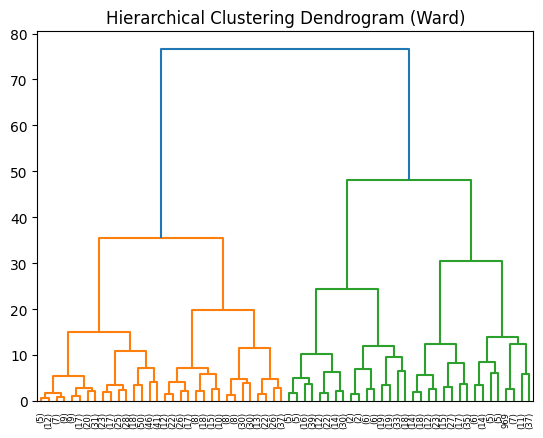

In [64]:
# Dendrogram
linked = linkage(X_standard, method='ward')

plt.figure()
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.show()

Dendrogram shows the hierarchical merging pattern in the unified feature space.

- We test robustness by comparing Ward vs KMeans (two different clustering methods).

- **High ARI (~0.878)**, both methods give very similar cluster assignments.

- Similar silhouette scores, cluster quality is consistent across methods.

- **Conclusion:** clusters are likely real structure, not just KMeans initialization.



## VIII. Cluster Stability Across Scaling: ARI

To quantify whether scaling changes the segmentation structure, we compute the Adjusted Rand Index (ARI) between the cluster assignments from the StandardScaler and MinMaxScaler pipelines (both using KMeans with the same k).

- A high ARI (close to 1) indicates the clusters are largely consistent across scaling choices.

- A low ARI (near 0) suggests that scaling materially changes the cluster assignments.

This step directly measures segmentation stability across preprocessing decisions.


In [65]:
ari_score = adjusted_rand_score(labels_standard, labels_minmax)
print("Adjusted Rand Index between scaling methods:", ari_score)

Adjusted Rand Index between scaling methods: 0.3745954654140135


- The ARI between StandardScaler and MinMaxScaler cluster labels is ~0.375, which indicates moderate agreement.
- Scaling does change cluster assignments for a meaningful subset of observations, so segmentation is somewhat sensitive to preprocessing choice.

## IX. Comparing Feature Sets: Silhouette Scores

To test whether integration improves clustering quality, we evaluate each team member’s original feature representation under the same standardized pipeline. For each feature set, we apply StandardScaler + KMeans (k = 3) and compare silhouette scores:

- Riya feature set (age gap only)

- Sanskruti feature set (raw actor ages)

- Daksh feature set (older/younger + gap)

- Unified feature set (combined features)

This ensures any performance differences come from the feature representation, not different preprocessing choices.


In [66]:
def evaluate_features(feature_set):
    X = StandardScaler().fit_transform(df[feature_set])
    labels = KMeans(n_clusters=3, random_state=42).fit_predict(X)
    score = silhouette_score(X, labels)
    return score

print("Riya silhouette:", evaluate_features(features_riya))
print("Sanskruti silhouette:", evaluate_features(features_sanskruti))
print("Daksh silhouette:", evaluate_features(features_daksh))
print("Unified silhouette:", evaluate_features(features_unified))


Riya silhouette: 0.5954125912830087
Sanskruti silhouette: 0.36983865719258513
Daksh silhouette: 0.42241671335682224
Unified silhouette: 0.4172817929664953


- Riya (age_gap only) has the highest silhouette (~0.595) → clearest cluster separation

- Daksh (older/younger + gap) is moderate (~0.422)

- Unified feature set is similar to Daksh (~0.417)

- Sanskruti (raw ages) is the lowest (~0.370)

**Takeaway:** Unified features don’t beat the best individual set, extra age variables may dilute separation rather than improve it

## X. Integration Attempts with Limited Gains

Not all integration steps led to better clustering performance. We found that:

- Adding multiple derived age features (unified set) did not improve silhouette compared to the best single feature set (age_gap).

- PCA helped compress the data into 2D for visualization, but the PCA plots still showed a continuous spread rather than clearly separated clusters.

- Changing scaling methods affected cluster assignments moderately (ARI ~0.375), but overall clustering quality remained in a similar range.

Overall, these results suggest that age gap magnitude already captures much of the dominant structure in this dataset. Documenting these outcomes still demonstrates meaningful integration effort and helps justify why simpler representations may be preferable.

## XI. Final Integrated Takeaways

Across the feature representations and preprocessing pipelines we evaluated, several consistent patterns emerged:

- The clustering results are moderately consistent across scaling methods, although scaling does shift a meaningful subset of observations between clusters.

- Age-gap magnitude captures much of the dominant structural signal and yields the strongest cluster separation in our comparisons.

- Additional derived age features support interpretation, but they do not materially improve segmentation quality beyond using age_gap alone.

- Overall, the Milestone 2 analyses were largely identifying overlapping underlying structure, despite using different feature choices.

Therefore, even though integration did not substantially improve clustering metrics, it strengthened our understanding of feature redundancy and preprocessing sensitivity in this dataset.
